In [ ]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#The final model results
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.863333,
        0.806667,
        0.851667,
        0.850000
    ],
    "Precision": [
        0.863840,
        0.806588,
        0.855712,
        0.849768
    ],
    "Recall": [
        0.863333,
        0.806667,
        0.851667,
        0.850000
    ],
    "F1_Score": [
        0.863542,
        0.806531,
        0.853045,
        0.849841
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.863333,0.863840,0.863333,0.863542
1,Decision Tree,0.806667,0.806588,0.806667,0.806531
2,Random Forest,0.851667,0.855712,0.851667,0.853045
3,XGBoost,0.850000,0.849768,0.850000,0.849841


In [ ]:
#Converting results to percentages
percentage_df = comparison_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score"
]

percentage_df[metric_columns] = (
    percentage_df[metric_columns] * 100
).round(2)

percentage_df


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,86.33,86.38,86.33,86.35
1,Decision Tree,80.67,80.66,80.67,80.65
2,Random Forest,85.17,85.57,85.17,85.30
3,XGBoost,85.00,84.98,85.00,84.98


In [ ]:
#Rank models by F1-score
ranked_models = percentage_df.sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)

ranked_models.index = ranked_models.index + 1

ranked_models

,Model,Accuracy,Precision,Recall,F1_Score
1,Logistic Regression,86.33,86.38,86.33,86.35
2,Random Forest,85.17,85.57,85.17,85.30
3,XGBoost,85.00,84.98,85.00,84.98
4,Decision Tree,80.67,80.66,80.67,80.65


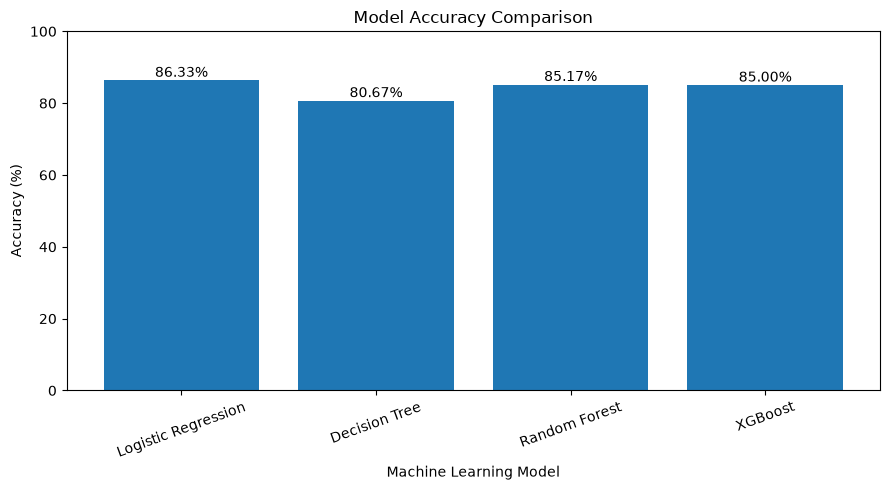

In [ ]:
#Plot for accuracy comparison
plt.figure(figsize=(9, 5))

plt.bar(
    percentage_df["Model"],
    percentage_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)

for index, value in enumerate(percentage_df["Accuracy"]):
    plt.text(
        index,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

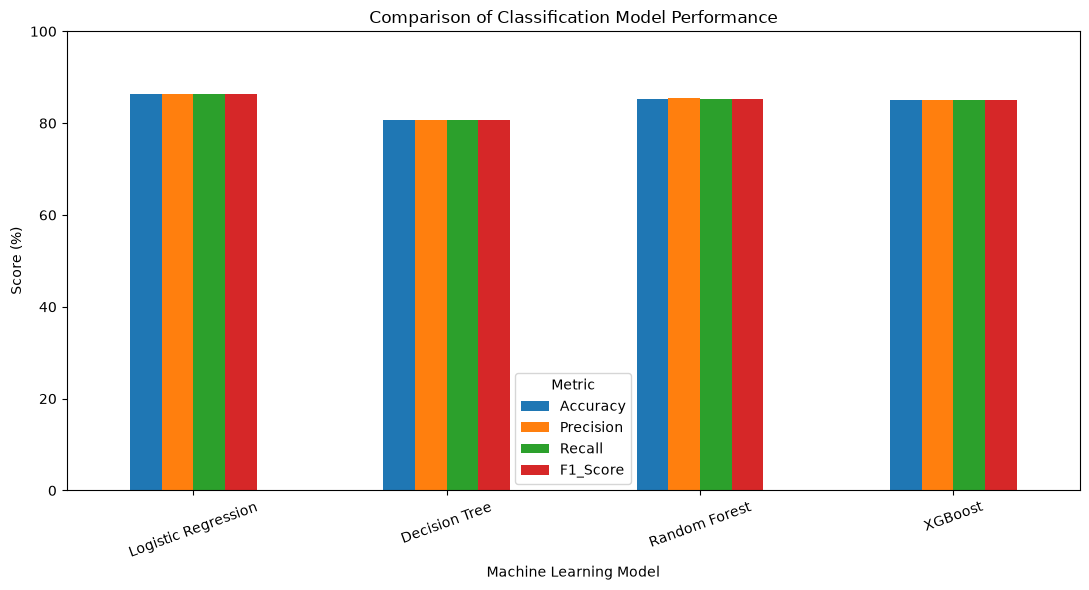

In [ ]:
#Plot for all evaluation metrics
plot_df = percentage_df.set_index("Model")

plot_df[
    ["Accuracy", "Precision", "Recall", "F1_Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of Classification Model Performance")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [ ]:
#Comparing training and testing accuracy
generalization_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Training_Accuracy": [
        88.75,
        93.708,
        95.7083,
        100.0000
    ],
    "Testing_Accuracy": [
        86.333,
        80.666,
        85.1667,
        85.0000
    ]
})

generalization_df["Accuracy_Gap"] = (
    generalization_df["Training_Accuracy"]
    - generalization_df["Testing_Accuracy"]
)

generalization_df.round(2)

,Model,Training_Accuracy,Testing_Accuracy,Accuracy_Gap
0,Logistic Regression,88.75,86.33,2.42
1,Decision Tree,93.71,80.67,13.04
2,Random Forest,95.71,85.17,10.54
3,XGBoost,100.00,85.00,15.00


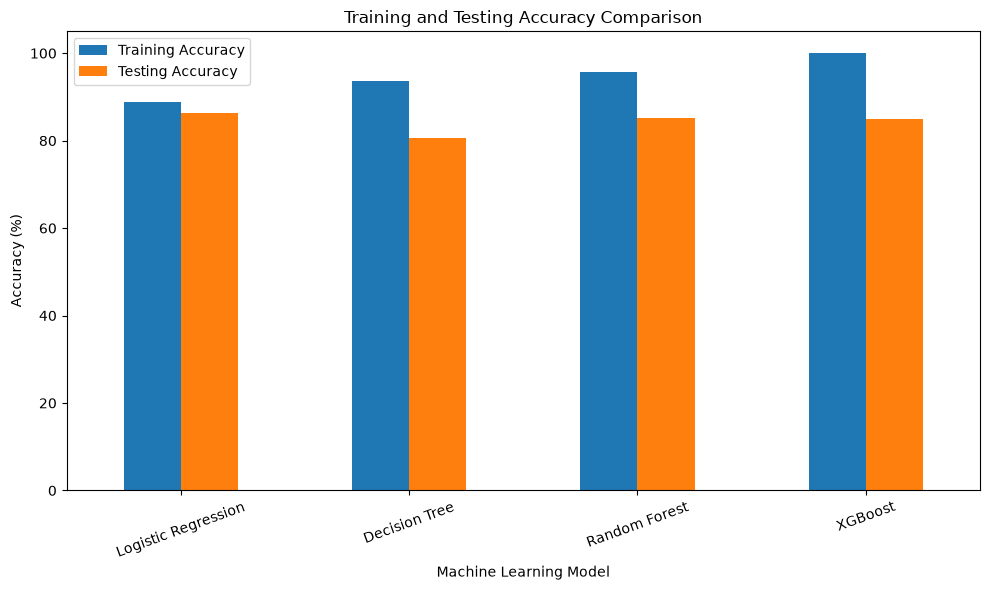

In [ ]:
#Plot for training vs testing accuracy
generalization_plot = generalization_df.set_index("Model")

generalization_plot[
    ["Training_Accuracy", "Testing_Accuracy"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Training and Testing Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.xticks(rotation=20)
plt.legend([
    "Training Accuracy",
    "Testing Accuracy"
])
plt.tight_layout()
plt.show()

In [ ]:
#Overfitting Check 
def interpret_gap(gap):
    if gap < 3:
        return "Low"
    elif gap < 8:
        return "Moderate"
    else:
        return "High"


generalization_df["Overfitting_Risk"] = (
    generalization_df["Accuracy_Gap"]
    .apply(interpret_gap)
)

generalization_df.round(2)

,Model,Training_Accuracy,Testing_Accuracy,Accuracy_Gap,Overfitting_Risk
0,Logistic Regression,88.75,86.33,2.42,Low
1,Decision Tree,93.71,80.67,13.04,High
2,Random Forest,95.71,85.17,10.54,High
3,XGBoost,100.00,85.00,15.00,High


In [ ]:
#Selecting the final model automatically
best_model_row = comparison_df.loc[
    comparison_df["F1_Score"].idxmax()
]

print("Selected Model:", best_model_row["Model"])
print("Accuracy:", best_model_row["Accuracy"])
print("F1 Score:", best_model_row["F1_Score"])

Selected Model: Logistic Regression
Accuracy: 0.863333
F1 Score: 0.863542


In [ ]:
#Saving the results
comparison_df.to_csv(
    "../reports/tables/model_comparison_results.csv",
    index=False
)

generalization_df.to_csv(
    "../reports/tables/model_generalization_results.csv",
    index=False
)

## Model Selection Conclusion

Four classification algorithms were evaluated - Logistic Regression,Decision Tree, Random Forest and XGBoost.

Logistic Regression achieved the highest testing accuracy of 86.33% and the highest weighted F1-score of approximately 86.35%. Random Forest and XGBoost achieved similar testing results but both showed larger gaps between training and testing accuracy, indicating a greater tendency to overfit the training data. The Decision Tree produced the lowest overall performance.

Therefore, Logistic Regression was selected as the final deployment model.The selection was based on test-set performance, weighted F1-score, generalization ability and model simplicity rather than algorithm complexity alone.